In [ ]:
#Importação das bibliotecas necessárias
import pandas as pd
import numpy as np
import re
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns
from sklearn.tree import plot_tree



In [ ]:
#Carregamento da base de dados
uniao = pd.read_csv('/content/state_idh_pib.csv')

In [ ]:
#COLUNA TARGET
#Verificação dos valories unicos para posteriormente reduzir o numero de faixas
uniao['Faixa_Salarial'].unique()

array(['de R$ 12.001/mês a R$ 16.000/mês',
       'de R$ 6.001/mês a R$ 8.000/mês', nan,
       'de R$ 4.001/mês a R$ 6.000/mês',
       'de R$ 8.001/mês a R$ 12.000/mês',
       'de R$ 20.001/mês a R$ 25.000/mês',
       'de R$ 1.001/mês a R$ 2.000/mês', 'de R$ 3.001/mês a R$ 4.000/mês',
       'de R$ 16.001/mês a R$ 20.000/mês',
       'de R$ 2.001/mês a R$ 3.000/mês', 'Acima de R$ 40.001/mês',
       'de R$ 25.001/mês a R$ 30.000/mês', 'Menos de R$ 1.000/mês',
       'de R$ 30.001/mês a R$ 40.000/mês', 'de R$ 101/mês a R$ 2.000/mês'],
      dtype=object)

In [ ]:
#Verificação dos dados NaN para posterior exclusão das linhas
total_nan = uniao['Faixa_Salarial'].isna().sum()
print(f"Total de valores NaN: {total_nan}")

Total de valores NaN: 540


In [ ]:
#Exclusão das linhas com valores Nan
uniao_filtrado = uniao.dropna(subset=['Faixa_Salarial'])

In [ ]:
#Verificação do resultado
contagem_valores = uniao_filtrado ['Faixa_Salarial'].value_counts()
print(contagem_valores)

Faixa_Salarial
de R$ 8.001/mês a R$ 12.000/mês     1026
de R$ 4.001/mês a R$ 6.000/mês       745
de R$ 12.001/mês a R$ 16.000/mês     650
de R$ 6.001/mês a R$ 8.000/mês       637
de R$ 3.001/mês a R$ 4.000/mês       352
de R$ 16.001/mês a R$ 20.000/mês     328
de R$ 2.001/mês a R$ 3.000/mês       288
de R$ 1.001/mês a R$ 2.000/mês       215
de R$ 20.001/mês a R$ 25.000/mês     195
de R$ 25.001/mês a R$ 30.000/mês     128
de R$ 30.001/mês a R$ 40.000/mês      86
Acima de R$ 40.001/mês                72
Menos de R$ 1.000/mês                 30
de R$ 101/mês a R$ 2.000/mês           1
Name: count, dtype: int64


In [ ]:
# Filtrar o DataFrame para excluir as linhas com a faixa salarial indesejada
uniao_filtrado = uniao_filtrado[uniao_filtrado['Faixa_Salarial'] != 'de R$ 101/mês a R$ 2.000/mês']

# Resetar o índice
uniao_filtrado = uniao_filtrado.reset_index(drop=True)

# Verificar o resultado
print(uniao_filtrado['Faixa_Salarial'].unique())  # Listar valores únicos para confirmar

['de R$ 12.001/mês a R$ 16.000/mês' 'de R$ 6.001/mês a R$ 8.000/mês'
 'de R$ 4.001/mês a R$ 6.000/mês' 'de R$ 8.001/mês a R$ 12.000/mês'
 'de R$ 20.001/mês a R$ 25.000/mês' 'de R$ 1.001/mês a R$ 2.000/mês'
 'de R$ 3.001/mês a R$ 4.000/mês' 'de R$ 16.001/mês a R$ 20.000/mês'
 'de R$ 2.001/mês a R$ 3.000/mês' 'Acima de R$ 40.001/mês'
 'de R$ 25.001/mês a R$ 30.000/mês' 'Menos de R$ 1.000/mês'
 'de R$ 30.001/mês a R$ 40.000/mês']


In [ ]:
##################### BDSCAN ###########################

#from sklearn.cluster import DBSCAN


#print("--- Iniciando a clusterização com DBSCAN ---")

# Passo 1: Criar o dicionário para mapear a faixa salarial para o seu ponto médio
#mapa_salario_medio = {
#    'Menos de R$ 1.000/mês': 500.0,
#    'de R$ 1.001/mês a R$ 2.000/mês': (1001 + 2000) / 2,
#    'de R$ 2.001/mês a R$ 3.000/mês': (2001 + 3000) / 2,
#    'de R$ 3.001/mês a R$ 4.000/mês': (3001 + 4000) / 2,
#    'de R$ 4.001/mês a R$ 6.000/mês': (4001 + 6000) / 2,
#    'de R$ 6.001/mês a R$ 8.000/mês': (6001 + 8000) / 2,
#    'de R$ 8.001/mês a R$ 12.000/mês': (8001 + 12000) / 2,
#    'de R$ 12.001/mês a R$ 16.000/mês': (12001 + 16000) / 2,
#    'de R$ 16.001/mês a R$ 20.000/mês': (16001 + 20000) / 2,
#    'de R$ 20.001/mês a R$ 25.000/mês': (20001 + 25000) / 2,
#    'de R$ 25.001/mês a R$ 30.000/mês': (25001 + 30000) / 2,
#    'de R$ 30.001/mês a R$ 40.000/mês': (30001 + 40000) / 2,
#    'Acima de R$ 40.001/mês': 50000.0 # Estimativa
#}

# Passo 2: Adicionar a coluna 'Salario_Medio' ao seu DataFrame existente
#uniao_filtrado['Salario_Medio'] = uniao_filtrado['Faixa_Salarial'].map(mapa_salario_medio)
#print("Coluna 'Salario_Medio' criada com sucesso.")

# Passo 3: Preparar os dados para o DBSCAN a partir da nova coluna
#X = uniao_filtrado['Salario_Medio'].values.reshape(-1, 1)

# Passo 4: Configurar e aplicar o DBSCAN
#dbscan = DBSCAN(eps=3000, min_samples=50)
#clusters = dbscan.fit_predict(X)

# Passo 5: Adicionar a coluna final com os resultados do cluster
#uniao_filtrado['Salario_target'] = clusters
#print("Coluna 'Salario_target' adicionada com sucesso.")


# --- Verificação Final ---
#print("\n--- Processo Concluído ---")
#print("\nLista de todas as colunas no DataFrame para confirmação:")
#print(uniao_filtrado.columns)

#print("\nVisualização das últimas 5 linhas com as novas colunas:")
#print(uniao_filtrado.tail())

#print("--- Análise dos Clusters Gerados pelo DBSCAN ---")
#print("\nContagem de pontos por cluster (label -1 é ruído/outlier):")
#print(uniao_filtrado['Salario_target'].value_counts())

#print("\nAnálise de cada cluster (faixa de salário):")
# O groupby nos mostra o que cada cluster representa em termos de salário
#cluster_analysis = uniao_filtrado.groupby('Salario_target')['Salario_Medio'].agg(['min', 'mean', 'max', 'count'])
#print(cluster_analysis)

##################### FIM BDSCAN ###########################

In [ ]:
##################### TERCIL pd.qcut ###########################

# 1. Criar o dicionário para mapear a faixa salarial para o seu ponto médio
# Para faixas abertas, usamos uma estimativa razoável.
mapa_salario_medio = {
    'Menos de R$ 1.000/mês': 500.0,
    'de R$ 1.001/mês a R$ 2.000/mês': (1001 + 2000) / 2,
    'de R$ 2.001/mês a R$ 3.000/mês': (2001 + 3000) / 2,
    'de R$ 3.001/mês a R$ 4.000/mês': (3001 + 4000) / 2,
    'de R$ 4.001/mês a R$ 6.000/mês': (4001 + 6000) / 2,
    'de R$ 6.001/mês a R$ 8.000/mês': (6001 + 8000) / 2,
    'de R$ 8.001/mês a R$ 12.000/mês': (8001 + 12000) / 2,
    'de R$ 12.001/mês a R$ 16.000/mês': (12001 + 16000) / 2,
    'de R$ 16.001/mês a R$ 20.000/mês': (16001 + 20000) / 2,
    'de R$ 20.001/mês a R$ 25.000/mês': (20001 + 25000) / 2,
    'de R$ 25.001/mês a R$ 30.000/mês': (25001 + 30000) / 2,
    'de R$ 30.001/mês a R$ 40.000/mês': (30001 + 40000) / 2,
    'Acima de R$ 40.001/mês': 50000.0 # Estimativa
}

# 2. ADICIONAR a nova coluna 'Salario_medio'
uniao_filtrado['Salario_medio'] = uniao_filtrado['Faixa_Salarial'].map(mapa_salario_medio)

# 3. ADICIONAR a nova coluna 'Salario_target' com base na coluna 'Salario_medio' usando pd.qcut
try:
    uniao_filtrado['Salario_target'], bin_edges = pd.qcut(
        uniao_filtrado['Salario_medio'],
        q=3,
        labels=[1, 2, 3], # Rótulos: 1 (baixo), 2 (médio), 3 (alto)
        retbins=True,
        duplicates='drop'
    )


except ValueError as e:
    print(f"Erro ao criar os tercis: {e}")
    print("Isso pode ocorrer se a distribuição dos dados não permitir 3 cortes únicos.")

print(uniao_filtrado['Salario_target'].value_counts().sort_index())

##################### FIM TERCIL pd.qcut ###########################

Salario_target
1    1630
2    1663
3    1459
Name: count, dtype: int64


In [ ]:
##################### KMEANS ###########################

#from sklearn.cluster import KMeans

#print("--- Iniciando o processo de clusterização K-Means ---")

# Passo 1: Definição do mapa para converter faixas salariais em valores numéricos.
#mapa_salario_medio = {
#    'Menos de R$ 1.000/mês': 500.0,
#    'de R$ 1.001/mês a R$ 2.000/mês': 1500.5,
#    'de R$ 2.001/mês a R$ 3.000/mês': 2500.5,
#    'de R$ 3.001/mês a R$ 4.000/mês': 3500.5,
#    'de R$ 4.001/mês a R$ 6.000/mês': 5000.5,
#    'de R$ 6.001/mês a R$ 8.000/mês': 7000.5,
#    'de R$ 8.001/mês a R$ 12.000/mês': 10000.5,
#    'de R$ 12.001/mês a R$ 16.000/mês': 14000.5,
#    'de R$ 16.001/mês a R$ 20.000/mês': 18000.5,
#    'de R$ 20.001/mês a R$ 25.000/mês': 22500.5,
#    'de R$ 25.001/mês a R$ 30.000/mês': 27500.5,
#    'de R$ 30.001/mês a R$ 40.000/mês': 35000.5,
#    'Acima de R$ 40.001/mês': 50000.0
#}

# Passo 2: Criação da coluna 'Salario_Medio'.
#if 'Salario_Medio' not in uniao_filtrado.columns:
#    uniao_filtrado['Salario_Medio'] = uniao_filtrado['Faixa_Salarial'].map(mapa_salario_medio)
#    print("Coluna 'Salario_Medio' foi criada.")
#else:
#    print("Coluna 'Salario_Medio' já existia.")

# PASSO EXTRA: Limpeza de valores nulos (NaN)
#nan_antes = uniao_filtrado['Salario_Medio'].isnull().sum()
#if nan_antes > 0:
#    print(f"Encontrados {nan_antes} valores nulos na coluna 'Salario_Medio'. Removendo as linhas correspondentes.")
#    uniao_filtrado.dropna(subset=['Salario_Medio'], inplace=True)
#    print("Linhas com valores nulos foram removidas.")

# Passo 3: Preparação dos dados para o modelo.
#X = uniao_filtrado['Salario_Medio'].values.reshape(-1, 1)

# Passo 4: Aplicação do K-Means.
#k = 4
#kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
#clusters = kmeans.fit_predict(X)

# Passo 5: Adição dos resultados ao DataFrame.
#uniao_filtrado['Salario_target'] = clusters
#print(f"Coluna 'Salario_target' com {k} grupos foi adicionada.")

# Passo 6: Análise e criação de uma coluna ordinal ordenada.
#cluster_analysis = uniao_filtrado.groupby('Salario_target')['Salario_Medio'].agg(['mean']).sort_values(by='mean')
#mapa_ordinal = cluster_analysis.reset_index().reset_index().set_index('Salario_target')['index']
#uniao_filtrado['KMeans_Ordinal'] = uniao_filtrado['Salario_target'].map(mapa_ordinal)
#print("Coluna 'KMeans_Ordinal' (ordenada) foi adicionada.")

# Passo 7: Verificação final.
#print("\n--- Processo Concluído ---")
#print("Lista de colunas no DataFrame final:")
#print(uniao_filtrado.columns)
#print("\nAmostra dos dados com as novas colunas:")
#print(uniao_filtrado[['Salario_Medio', 'Salario_target', 'KMeans_Ordinal']].head())
#contagem_valores = uniao_filtrado['Salario_target'].value_counts(dropna=False)
#print(contagem_valores)

##################### FIM KMEANS ###########################

In [ ]:
# Contar valores NaN antes da exclusão
print(f"Total de linhas ANTES da exclusão: {len(uniao_filtrado)}")
print(f"Valores NaN na coluna 'Uf': {uniao_filtrado['Uf'].isna().sum()}")

# Excluir linhas com NaN na coluna 'Uf'
uniao_filtrado = uniao_filtrado.dropna(subset=['Uf'])

# Verificar resultado
print(f"\nTotal de linhas APÓS exclusão: {len(uniao_filtrado)}")
print(f"Valores NaN restantes em 'Uf': {uniao_filtrado['Uf'].isna().sum()}")

Total de linhas ANTES da exclusão: 4752
Valores NaN na coluna 'Uf': 103

Total de linhas APÓS exclusão: 4649
Valores NaN restantes em 'Uf': 0


In [ ]:
#Contagem de valores únicos
contagem_valores = uniao_filtrado['Nivel_de_Ensino'].value_counts(dropna=False)
print(contagem_valores)

Nivel_de_Ensino
Pós-graduação                 1671
Graduação/Bacharelado         1612
Mestrado                       572
Estudante de Graduação         529
Doutorado ou Phd               181
Não tenho graduação formal      79
Prefiro não informar             5
Name: count, dtype: int64


In [ ]:
# Valores que serão removidos
valores_remover = ['Não tenho graduação formal', 'Prefiro não informar']

# Filtrar o DataFrame, mantendo apenas as linhas que NÃO estão nos valores a remover
uniao_filtrado = uniao_filtrado[~uniao_filtrado['Nivel_de_Ensino'].isin(valores_remover)]

# Verificar o resultado
print("Valores únicos em 'Nivel_de_Ensino' após exclusão:")
print(uniao_filtrado['Nivel_de_Ensino'].value_counts())

Valores únicos em 'Nivel_de_Ensino' após exclusão:
Nivel_de_Ensino
Pós-graduação             1671
Graduação/Bacharelado     1612
Mestrado                   572
Estudante de Graduação     529
Doutorado ou Phd           181
Name: count, dtype: int64


In [ ]:
# Dicionário de mapeamento
mapeamento = {
    'Estudante de Graduação': 1,
    'Graduação/Bacharelado': 2,
    'Pós-graduação': 3,
    'Mestrado': 4,
    'Doutorado ou Phd': 4
}

# Substitui a coluna original
uniao_filtrado['Nivel_de_Ensino'] = uniao_filtrado['Nivel_de_Ensino'].map(mapeamento)
print(uniao_filtrado['Nivel_de_Ensino'].value_counts())

Nivel_de_Ensino
3    1671
2    1612
4     753
1     529
Name: count, dtype: int64


<ipython-input-14-185170360>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  uniao_filtrado['Nivel_de_Ensino'] = uniao_filtrado['Nivel_de_Ensino'].map(mapeamento)


In [ ]:
# Contagem de valores unicos coluna 'Area_de_Formacao'
contagem_valores = uniao_filtrado['Tempo_de_experiencia_na_area_de_dados'].value_counts(dropna=False)
print(contagem_valores)

Tempo_de_experiencia_na_area_de_dados
de 1 a 2 anos                             1161
de 3 a 4 anos                             1075
Mais de 10 anos                            529
Menos de 1 ano                             454
de 4 a 6 anos                              440
de 7 a 10 anos                             403
de 5 a 6 anos                              349
Não tenho experiência na área de dados     154
Name: count, dtype: int64


In [ ]:
# Passo 1: Limpeza - Unificar as categorias sobrepostas para consistência.
uniao_filtrado['Tempo_de_experiencia_na_area_de_dados'] = uniao_filtrado['Tempo_de_experiencia_na_area_de_dados'].replace({
    'de 5 a 6 anos': 'de 4 a 6 anos'
})
print("Categorias sobrepostas foram unificadas.")

# Passo 2: Mapeamento Lógico para 4 Níveis Numéricos (1 a 4)
# 1 = Iniciante, 2 = Intermediário, 3 = Avançado, 4 = Especialista
mapa_experiencia_ordinal = {
    'Não tenho experiência na área de dados': 1,
    'Menos de 1 ano': 1,
    'de 1 a 2 anos': 2,
    'de 3 a 4 anos': 3,
    'de 4 a 6 anos': 3,
    'de 7 a 10 anos': 4,
    'Mais de 10 anos': 4
}

# Passo 3: Adicionar a nova coluna numérica 'Nivel_Experiencia_Ordinal'
uniao_filtrado['Nivel_Experiencia_Ordinal'] = uniao_filtrado['Tempo_de_experiencia_na_area_de_dados'].map(mapa_experiencia_ordinal)
print("Nova coluna 'Nivel_Experiencia_Ordinal' foi adicionada com sucesso.")

print("\n--- Processo Concluído ---")
print("\nContagem de profissionais em cada novo nível numérico:")
print(uniao_filtrado['Nivel_Experiencia_Ordinal'].value_counts().sort_index())

print("\nLista de todas as colunas para confirmar que nenhuma foi perdida:")
print(uniao_filtrado.columns)

print("\nAmostra do DataFrame mostrando a conversão:")
print(uniao_filtrado[['Tempo_de_experiencia_na_area_de_dados', 'Nivel_Experiencia_Ordinal']].head())

Categorias sobrepostas foram unificadas.
Nova coluna 'Nivel_Experiencia_Ordinal' foi adicionada com sucesso.

--- Processo Concluído ---

Contagem de profissionais em cada novo nível numérico:
Nivel_Experiencia_Ordinal
1     608
2    1161
3    1864
4     932
Name: count, dtype: int64

Lista de todas as colunas para confirmar que nenhuma foi perdida:
Index(['Idade', 'Faixa de idade', 'Genero', 'Cor/Raça/Etnia', 'PDC',
       'Estado_onde_mora', 'Uf', 'Regiao_onde_mora', 'Mudou_de_estado',
       'Regiao_de_Origem', 'Nivel_de_Ensino', 'Area_de_Formacao',
       'Situacao_atual_de_trabalho', 'Setor', 'Num_func_empresa_que_trabalha',
       'Cargo_Atual', 'Nível', 'Faixa_Salarial', 'Salario_Medio',
       'Tempo_de_experiencia_na_area_de_dados', 'Atual_forma_de_trabalho',
       'Papeis/cargos_do_time/chapter_de_dados', 'Analytics_Engineer',
       'Engenharia_de_Dados/Data_Engineer', 'Analista_de_Dados/Data_Analyst',
       'Cientista_de_Dados/Data_Scientist', 'Database_Administrator/DBA'

<ipython-input-16-3746584311>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  uniao_filtrado['Tempo_de_experiencia_na_area_de_dados'] = uniao_filtrado['Tempo_de_experiencia_na_area_de_dados'].replace({
<ipython-input-16-3746584311>:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  uniao_filtrado['Nivel_Experiencia_Ordinal'] = uniao_filtrado['Tempo_de_experiencia_na_area_de_dados'].map(mapa_experiencia_ordinal)


In [ ]:
# 1. Lista de todas as colunas de linguagens
lista_colunas_linguagens = [
    'SQL', 'R', 'Python', 'C/C++/C#', 'NET', 'Java',
    'Julia', 'SAS/Stata', 'Visual Basic/VBA', 'Scala', 'Matlab', 'Rust',
    'PHP', 'JavaScript', 'Não utilizo nenhuma linguagem'
]

# 2. Crie um dicionário para armazenar as contagens
contagens_linguagens = {}

print("--- Iniciando a contagem de uso de linguagens de programação ---")
# 3. Itere sobre a lista e some cada coluna correspondente no DataFrame
for linguagem in lista_colunas_linguagens:
    # Checa se a coluna realmente existe no DataFrame antes de tentar somar
    if linguagem in uniao_filtrado.columns:
        # Soma a coluna. Isso funciona se 'sim'=1 e 'não'=0.
        total = uniao_filtrado[linguagem].sum()
        contagens_linguagens[linguagem] = total
    else:
        # Se a coluna não for encontrada, informa e segue para a próxima
        print(f"Aviso: A coluna '{linguagem}' não foi encontrada e será ignorada.")

# 4. Converter o dicionário em uma Série do Pandas para facilitar a manipulação
contagens_series_linguagens = pd.Series(contagens_linguagens).astype(int)

# Exibir as contagens encontradas
print("\n--- Contagem de cada linguagem (soma da coluna) ---")
print(contagens_series_linguagens)

--- Iniciando a contagem de uso de linguagens de programação ---

--- Contagem de cada linguagem (soma da coluna) ---
SQL                              3045
R                                 397
Python                           2726
C/C++/C#                           63
NET                                36
Java                              336
Julia                               8
SAS/Stata                         150
Visual Basic/VBA                  276
Scala                             126
Matlab                             28
Rust                                7
PHP                                54
JavaScript                        264
Não utilizo nenhuma linguagem     287
dtype: int64


In [ ]:
# 1. Lista de todas as colunas de ferramentas
lista_colunas_ferramentas = [
    'Azure (Microsoft)', 'Amazon Web Services (AWS)', 'Google Cloud (GCP)',
    'Oracle Cloud', 'IBM', 'Servidores On Premise/Não utilizamos Cloud',
    'Cloud Própria', 'Microsoft PowerBI', 'Qlik View/Qlik Sense', 'Tableau',
    'Metabase', 'Superset', 'Redash', 'Looker','Looker Studio(Google Data Studio)',
    'Amazon Quicksight', 'Mode', 'Alteryx', 'MicroStrategy', 'IBM Analytics/Cognos',
    'SAP Business Objects/SAP Analytics', 'Oracle Business Intelligence',
    'Salesforce/Einstein Analytics', 'Birst', 'SAS Visual Analytics',
    'Grafana', 'TIBCO Spotfire', 'Pentaho',
    'Fazemos todas as análises utilizando apenas Excel ou planilhas do google',
    'Não utilizo nenhuma ferramenta de BI no trabalho'
]

# 2. Crie um dicionário para armazenar as contagens
contagens_ferramentas = {}

print("--- Iniciando a contagem de uso de ferramentas de programação ---")
# 3. Itere sobre a lista e some cada coluna correspondente no DataFrame
for ferramentas in lista_colunas_ferramentas:
    # Checa se a coluna realmente existe no DataFrame antes de tentar somar
    if ferramentas in uniao_filtrado.columns:
        # Soma a coluna. Isso funciona se 'sim'=1 e 'não'=0.
        total = uniao_filtrado[ferramentas].sum()
        contagens_ferramentas[ferramentas] = total
    else:
        # Se a coluna não for encontrada, informa e segue para a próxima
        print(f"Aviso: A coluna '{ferramentas}' não foi encontrada e será ignorada.")

# 4. Converter o dicionário em uma Série do Pandas para facilitar a manipulação
contagens_series_ferramentas = pd.Series(contagens_ferramentas).astype(int)

# Exibir as contagens encontradas
print("\n--- Contagem de cada ferramentas (soma da coluna) ---")
print(contagens_series_ferramentas)

--- Iniciando a contagem de uso de ferramentas de programação ---

--- Contagem de cada ferramentas (soma da coluna) ---
Azure (Microsoft)                                                           1481
Amazon Web Services (AWS)                                                   1057
Google Cloud (GCP)                                                          1091
Oracle Cloud                                                                 149
IBM                                                                           44
Servidores On Premise/Não utilizamos Cloud                                   562
Cloud Própria                                                                245
Microsoft PowerBI                                                           2069
Qlik View/Qlik Sense                                                         184
Tableau                                                                      681
Metabase                                                             

In [ ]:
# 1. Defina as listas originais de colunas
lista_completa_linguagens = [
    'SQL', 'R', 'Python', 'C/C++/C#', 'NET', 'Java',
    'Julia', 'SAS/Stata', 'Visual Basic/VBA', 'Scala', 'Matlab', 'Rust',
    'PHP', 'JavaScript', 'Não utilizo nenhuma linguagem'
]

lista_completa_ferramentas = [
    'Azure (Microsoft)', 'Amazon Web Services (AWS)', 'Google Cloud (GCP)',
    'Oracle Cloud', 'IBM', 'Servidores On Premise/Não utilizamos Cloud',
    'Cloud Própria', 'Microsoft PowerBI', 'Qlik View/Qlik Sense', 'Tableau',
    'Metabase', 'Superset', 'Redash', 'Looker','Looker Studio(Google Data Studio)',
    'Amazon Quicksight', 'Mode', 'Alteryx', 'MicroStrategy', 'IBM Analytics/Cognos',
    'SAP Business Objects/SAP Analytics', 'Oracle Business Intelligence',
    'Salesforce/Einstein Analytics', 'Birst', 'SAS Visual Analytics',
    'Grafana', 'TIBCO Spotfire', 'Pentaho',
    'Fazemos todas as análises utilizando apenas Excel ou planilhas do google',
    'Não utilizo nenhuma ferramenta de BI no trabalho'
]

# 2. Defina as colunas que você quer EXCLUIR da contagem
colunas_para_excluir = [
    'Não utilizo nenhuma linguagem',
    'Fazemos todas as análises utilizando apenas Excel ou planilhas do google',
    'Não utilizo nenhuma ferramenta de BI no trabalho'
]

# 3. Crie as listas finais de contagem, removendo as colunas indesejadas
lista_linguagens = [lang for lang in lista_completa_linguagens if lang not in colunas_para_excluir]
lista_ferramentas = [tool for tool in lista_completa_ferramentas if tool not in colunas_para_excluir]


# 4. Garantir que apenas colunas existentes no seu DataFrame sejam usadas
colunas_linguagens_existentes = [col for col in lista_linguagens if col in uniao_filtrado.columns]
colunas_ferramentas_existentes = [col for col in lista_ferramentas if col in uniao_filtrado.columns]

# 5. Criar a nova feature somando as colunas filtradas
uniao_filtrado['total_linguagens'] = uniao_filtrado[colunas_linguagens_existentes].sum(axis=1)
uniao_filtrado['total_ferramentas'] = uniao_filtrado[colunas_ferramentas_existentes].sum(axis=1)

print("Novas features de contagem de habilidades criadas (excluindo opções de 'não uso'):")
print(uniao_filtrado[['total_linguagens', 'total_ferramentas']].head())

Novas features de contagem de habilidades criadas (excluindo opções de 'não uso'):
   total_linguagens  total_ferramentas
0               2.0                1.0
1               2.0                4.0
2               3.0                5.0
3               2.0                2.0
4               2.0                4.0


<ipython-input-19-1248592420>:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  uniao_filtrado['total_linguagens'] = uniao_filtrado[colunas_linguagens_existentes].sum(axis=1)
<ipython-input-19-1248592420>:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  uniao_filtrado['total_ferramentas'] = uniao_filtrado[colunas_ferramentas_existentes].sum(axis=1)


In [ ]:
contagem_valores = uniao_filtrado['total_linguagens'].value_counts(dropna=False)
print(contagem_valores)

total_linguagens
2.0    1852
0.0    1207
1.0     604
3.0     552
4.0     245
5.0      73
6.0      21
7.0       8
8.0       2
9.0       1
Name: count, dtype: int64


In [ ]:
contagem_valores = uniao_filtrado['total_ferramentas'].value_counts(dropna=False)
print(contagem_valores)

total_ferramentas
2.0     1269
0.0      979
3.0      810
4.0      573
1.0      446
5.0      261
6.0      130
7.0       46
8.0       30
9.0       10
10.0       5
11.0       3
12.0       2
13.0       1
Name: count, dtype: int64


In [ ]:
### ENGENHARIA DE FEATURE #######
# CRIAÇÃO DE DUAS NOVAS COLUNAS. UMA QUE AGRUPA O UTILIZAÇÃO DE LIGUAGEM DE PROGRAMAÇÃO E OUTRA PARA AGRUPAR UTILIZAÇÃO DE FERRAENTAS
# 1. Agrupamento da coluna 'total_linguagens'
def agrupa_linguagens(total):
    if total < 1:
        return 'Nenhuma Linguagem'
    elif total == 1:
        return '1 Linguagem'
    elif total == 2:
        return '2 Linguagens'
    else: # total >= 3
        return '3 ou mais Linguagens'

uniao_filtrado['Grupo_Linguagens'] = uniao_filtrado['total_linguagens'].apply(agrupa_linguagens)
print("Coluna 'Grupo_Linguagens' criada com sucesso.")


# 2. Agrupamento da coluna 'total_ferramentas'
def agrupa_ferramentas(total):
    if total < 1:
        return 'Nenhuma Ferramenta'
    elif total == 1:
        return '1 Ferramenta'
    elif total == 2:
        return '2 Ferramentas'
    else: # total >= 3
        return '3 ou mais Ferramentas'

uniao_filtrado['Grupo_Ferramentas'] = uniao_filtrado['total_ferramentas'].apply(agrupa_ferramentas)
print("Coluna 'Grupo_Ferramentas' criada com sucesso.")


# --- Verificação Final ---
print("\n--- Processo Concluído ---")
print("\nContagem de profissionais por grupo de linguagens:")
print(uniao_filtrado['Grupo_Linguagens'].value_counts())

print("\nContagem de profissionais por grupo de ferramentas:")
print(uniao_filtrado['Grupo_Ferramentas'].value_counts())

print("\nAmostra do DataFrame com as novas colunas:")
print(uniao_filtrado[['total_linguagens', 'Grupo_Linguagens', 'total_ferramentas', 'Grupo_Ferramentas']].head())

Coluna 'Grupo_Linguagens' criada com sucesso.
Coluna 'Grupo_Ferramentas' criada com sucesso.

--- Processo Concluído ---

Contagem de profissionais por grupo de linguagens:
Grupo_Linguagens
2 Linguagens            1852
Nenhuma Linguagem       1207
3 ou mais Linguagens     902
1 Linguagem              604
Name: count, dtype: int64

Contagem de profissionais por grupo de ferramentas:
Grupo_Ferramentas
3 ou mais Ferramentas    1871
2 Ferramentas            1269
Nenhuma Ferramenta        979
1 Ferramenta              446
Name: count, dtype: int64

Amostra do DataFrame com as novas colunas:
   total_linguagens      Grupo_Linguagens  total_ferramentas  \
0               2.0          2 Linguagens                1.0   
1               2.0          2 Linguagens                4.0   
2               3.0  3 ou mais Linguagens                5.0   
3               2.0          2 Linguagens                2.0   
4               2.0          2 Linguagens                4.0   

       Grupo_Ferrament

<ipython-input-22-1081814269>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  uniao_filtrado['Grupo_Linguagens'] = uniao_filtrado['total_linguagens'].apply(agrupa_linguagens)
<ipython-input-22-1081814269>:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  uniao_filtrado['Grupo_Ferramentas'] = uniao_filtrado['total_ferramentas'].apply(agrupa_ferramentas)


In [ ]:
#INCLUIDO VALORES NUMEROS ORDINAIS PARA USO DE LIGUAGENS E FERRAMENTAS.
if 'Grupo_Linguagens' not in uniao_filtrado.columns or 'Grupo_Ferramentas' not in uniao_filtrado.columns:
    print("ERRO: As colunas 'Grupo_Linguagens' ou 'Grupo_Ferramentas' não foram encontradas.")
    print("Por favor, execute o script de agrupamento anterior primeiro.")
else:
    print("--- Iniciando a codificação ordinal das colunas de grupo ---")

    # 1. Mapeamento para a coluna 'Grupo_Linguagens'
    # Definimos a ordem e o valor numérico correspondente para cada categoria.
    mapa_linguagens_ordinal = {
        'Nenhuma Linguagem': 1,
        '1 Linguagem': 2,
        '2 Linguagens': 3,
        '3 ou mais Linguagens': 4
    }
    uniao_filtrado['Grupo_Linguagens_Ordinal'] = uniao_filtrado['Grupo_Linguagens'].map(mapa_linguagens_ordinal)
    print("Coluna 'Grupo_Linguagens_Ordinal' criada com sucesso.")


    # 2. Mapeamento para a coluna 'Grupo_Ferramentas'
    mapa_ferramentas_ordinal = {
        'Nenhuma Ferramenta': 1,
        '1 Ferramenta': 2,
        '2 Ferramentas': 3,
        '3 ou mais Ferramentas': 4
    }
    uniao_filtrado['Grupo_Ferramentas_Ordinal'] = uniao_filtrado['Grupo_Ferramentas'].map(mapa_ferramentas_ordinal)
    print("Coluna 'Grupo_Ferramentas_Ordinal' criada com sucesso.")


    # --- Verificação Final ---
    print("\n--- Processo Concluído ---")
    print("\nLista completa de colunas no DataFrame:")
    print(uniao_filtrado.columns)

    print("\nAmostra do DataFrame mostrando as novas colunas ordinais:")
    # Selecionando colunas relevantes para a verificação
    colunas_para_verificar = [
        'Grupo_Linguagens', 'Grupo_Linguagens_Ordinal',
        'Grupo_Ferramentas', 'Grupo_Ferramentas_Ordinal'
    ]
    print(uniao_filtrado[colunas_para_verificar].sample(5))

--- Iniciando a codificação ordinal das colunas de grupo ---
Coluna 'Grupo_Linguagens_Ordinal' criada com sucesso.
Coluna 'Grupo_Ferramentas_Ordinal' criada com sucesso.

--- Processo Concluído ---

Lista completa de colunas no DataFrame:
Index(['Idade', 'Faixa de idade', 'Genero', 'Cor/Raça/Etnia', 'PDC',
       'Estado_onde_mora', 'Uf', 'Regiao_onde_mora', 'Mudou_de_estado',
       'Regiao_de_Origem', 'Nivel_de_Ensino', 'Area_de_Formacao',
       'Situacao_atual_de_trabalho', 'Setor', 'Num_func_empresa_que_trabalha',
       'Cargo_Atual', 'Nível', 'Faixa_Salarial', 'Salario_Medio',
       'Tempo_de_experiencia_na_area_de_dados', 'Atual_forma_de_trabalho',
       'Papeis/cargos_do_time/chapter_de_dados', 'Analytics_Engineer',
       'Engenharia_de_Dados/Data_Engineer', 'Analista_de_Dados/Data_Analyst',
       'Cientista_de_Dados/Data_Scientist', 'Database_Administrator/DBA',
       'Analista_de_Business_Intelligence/BI',
       'Arquiteto_de_Dados/Data_Architect', 'Data_Product_Manage

<ipython-input-23-2059969242>:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  uniao_filtrado['Grupo_Linguagens_Ordinal'] = uniao_filtrado['Grupo_Linguagens'].map(mapa_linguagens_ordinal)
<ipython-input-23-2059969242>:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  uniao_filtrado['Grupo_Ferramentas_Ordinal'] = uniao_filtrado['Grupo_Ferramentas'].map(mapa_ferramentas_ordinal)


In [ ]:
contagem_valores = uniao_filtrado['Grupo_Linguagens'].value_counts(dropna=False)
print(contagem_valores)

Grupo_Linguagens
2 Linguagens            1852
Nenhuma Linguagem       1207
3 ou mais Linguagens     902
1 Linguagem              604
Name: count, dtype: int64


In [ ]:
# Definir quais colunas indicam especialização em Cloud
cols_cloud = ['Azure (Microsoft)', 'Amazon Web Services (AWS)', 'Google Cloud (GCP)']
# Garantir que as colunas existem
cols_cloud_existentes = [col for col in cols_cloud if col in uniao_filtrado.columns]

# Definir quais colunas indicam especialização em BI
cols_bi = ['Microsoft PowerBI', 'Qlik View/Qlik Sense', 'Tableau', 'Looker Studio(Google Data Studio)']
cols_bi_existentes = [col for col in cols_bi if col in uniao_filtrado.columns]

# Criar as meta-features
if cols_cloud_existentes:
    # Se a soma das colunas de cloud for > 0, então a pessoa usa pelo menos uma.
    uniao_filtrado['usa_cloud'] = (uniao_filtrado[cols_cloud_existentes].sum(axis=1) > 0).astype(int)

if cols_bi_existentes:
    # Se a soma das colunas de BI for > 0, então a pessoa usa pelo menos uma.
    uniao_filtrado['usa_ferramenta_bi'] = (uniao_filtrado[cols_bi_existentes].sum(axis=1) > 0).astype(int)

print("\nNovas meta-features de especialização criadas:")
# Mostrando apenas as novas colunas para o exemplo
if 'usa_cloud' in uniao_filtrado.columns and 'usa_ferramenta_bi' in uniao_filtrado.columns:
    print(uniao_filtrado[['usa_cloud', 'usa_ferramenta_bi']].head())


Novas meta-features de especialização criadas:
   usa_cloud  usa_ferramenta_bi
0          1                  0
1          1                  1
2          1                  1
3          0                  1
4          1                  1


<ipython-input-25-3670848232>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  uniao_filtrado['usa_cloud'] = (uniao_filtrado[cols_cloud_existentes].sum(axis=1) > 0).astype(int)
<ipython-input-25-3670848232>:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  uniao_filtrado['usa_ferramenta_bi'] = (uniao_filtrado[cols_bi_existentes].sum(axis=1) > 0).astype(int)


In [ ]:
contagem_valores = uniao_filtrado['Idade'].value_counts(dropna=False)
print(contagem_valores)

Idade
27    338
28    322
29    302
30    295
26    287
31    264
32    237
25    219
33    219
34    207
24    178
35    177
23    163
36    157
37    146
38    115
22     96
40     93
41     84
39     78
42     77
43     59
21     55
44     53
45     37
20     34
48     34
47     32
46     31
51     26
53     19
50     19
19     17
49     17
52     17
55     12
56      9
54      8
18      7
57      7
58      4
60      3
69      2
59      2
64      2
70      1
61      1
63      1
62      1
66      1
Name: count, dtype: int64


In [ ]:
print("--- Iniciando o agrupamento da coluna 'Idade' por quantis ---")

# Aplicar o pd.qcut para dividir em 4 grupos (quartis)
# Esta operação cria e adiciona a nova coluna 'Idade_Quartil'.
try:
    uniao_filtrado['Idade_Quartil'], bin_edges = pd.qcut(
        uniao_filtrado['Idade'],
        q=4,
        labels=[0, 1, 2, 3], # Rótulos numéricos para os grupos
        retbins=True, # Para nos mostrar os pontos de corte
        duplicates='drop' # Evita erros com valores duplicados
    )

    print("Coluna 'Idade_Quartil' adicionada com sucesso!")

    # --- Verificação Final ---
    print("\n--- Resultado do Agrupamento por Quantis ---")
    print("\nContagem de pessoas por quartil (grupos balanceados):")
    print(uniao_filtrado['Idade_Quartil'].value_counts().sort_index())

    print("\nFaixas de Idade para cada quartil:")
    for i in range(len(bin_edges) - 1):
        print(f"Grupo {i}: de {bin_edges[i]:.0f} a {bin_edges[i+1]:.0f} anos")

    print("\nLista de TODAS as colunas para confirmar que nenhuma foi perdida:")
    print(uniao_filtrado.columns)

except Exception as e:
    print(f"\nOcorreu um erro durante a execução: {e}")
    print("Por favor, verifique se a coluna 'Idade' existe e contém dados numéricos.")

--- Iniciando o agrupamento da coluna 'Idade' por quantis ---
Coluna 'Idade_Quartil' adicionada com sucesso!

--- Resultado do Agrupamento por Quantis ---

Contagem de pessoas por quartil (grupos balanceados):
Idade_Quartil
0    1394
1     919
2    1261
3     991
Name: count, dtype: int64

Faixas de Idade para cada quartil:
Grupo 0: de 18 a 27 anos
Grupo 1: de 27 a 30 anos
Grupo 2: de 30 a 36 anos
Grupo 3: de 36 a 70 anos

Lista de TODAS as colunas para confirmar que nenhuma foi perdida:
Index(['Idade', 'Faixa de idade', 'Genero', 'Cor/Raça/Etnia', 'PDC',
       'Estado_onde_mora', 'Uf', 'Regiao_onde_mora', 'Mudou_de_estado',
       'Regiao_de_Origem', 'Nivel_de_Ensino', 'Area_de_Formacao',
       'Situacao_atual_de_trabalho', 'Setor', 'Num_func_empresa_que_trabalha',
       'Cargo_Atual', 'Nível', 'Faixa_Salarial', 'Salario_Medio',
       'Tempo_de_experiencia_na_area_de_dados', 'Atual_forma_de_trabalho',
       'Papeis/cargos_do_time/chapter_de_dados', 'Analytics_Engineer',
       'E

In [ ]:
# Contagem de valores unicos coluna 'Azure (Microsoft)'
contagem_valores = uniao_filtrado['Azure (Microsoft)'].value_counts(dropna=False)
print(contagem_valores)

Azure (Microsoft)
0.0    1998
1.0    1481
NaN    1086
Name: count, dtype: int64


In [ ]:
# Substitui NaN por 0 na coluna 'Azure (Microsoft)'
uniao_filtrado['Azure (Microsoft)'] = uniao_filtrado['Azure (Microsoft)'].fillna(0)

# Verifica o resultado
print("Valores na coluna 'Azure (Microsoft)' após substituição:")
print(uniao_filtrado['Azure (Microsoft)'].value_counts(dropna=False))

Valores na coluna 'Azure (Microsoft)' após substituição:
Azure (Microsoft)
0.0    3084
1.0    1481
Name: count, dtype: int64


In [ ]:
# Contagem de valores unicos coluna 'Google Cloud (GCP)'
contagem_valores = uniao_filtrado['Google Cloud (GCP)'].value_counts(dropna=False)
print(contagem_valores)

Google Cloud (GCP)
0.0    2388
1.0    1091
NaN    1086
Name: count, dtype: int64


In [ ]:
# Substitui NaN por 0 na coluna 'Python'
uniao_filtrado['Google Cloud (GCP)'] = uniao_filtrado['Google Cloud (GCP)'].fillna(0)

# Verifica o resultado
print("Valores na coluna 'Google Cloud (GCP)' após substituição:")
print(uniao_filtrado['Google Cloud (GCP)'].value_counts(dropna=False))

Valores na coluna 'Google Cloud (GCP)' após substituição:
Google Cloud (GCP)
0.0    3474
1.0    1091
Name: count, dtype: int64


In [ ]:
# Contagem de valores unicos coluna 'Nível'
contagem_valores = uniao_filtrado['Nível'].value_counts(dropna=False)
print(contagem_valores)

Nível
Sênior    1369
Pleno     1341
Júnior    1002
NaN        853
Name: count, dtype: int64


In [ ]:
# Mapeamento desejado
mapeamento_nivel = {
    "Sênior": 3,
    "Pleno": 2,
    "Júnior": 1
}

# Aplicando o mapeamento
uniao_filtrado["Nível"] = uniao_filtrado["Nível"].map(mapeamento_nivel)
# Contagem de valores unicos coluna 'Nível'
contagem_valores = uniao_filtrado['Nível'].value_counts(dropna=False)
print(contagem_valores)

Nível
3.0    1369
2.0    1341
1.0    1002
NaN     853
Name: count, dtype: int64


In [ ]:
# Converter todos os valores para string (incluindo os números)
uniao_filtrado['Nível'] = uniao_filtrado['Nível'].astype(str)

# Agora aplicar o OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, dtype=np.int8)
nivel_encoded = encoder.fit_transform(uniao_filtrado[['Nível']])

# Criar colunas com prefixo
colunas_encoded = [f"Nível_{cat}" for cat in encoder.categories_[0]]
df_encoded = pd.DataFrame(nivel_encoded, columns=colunas_encoded, index=uniao_filtrado.index)

# Concatenar com o DataFrame original
uniao_filtrado = pd.concat([uniao_filtrado.drop(columns=['Nível']), df_encoded], axis=1)


In [ ]:
# Contagem de valores unicos coluna 'Setor'
contagem_valores = uniao_filtrado['Setor'].value_counts(dropna=False)
print(contagem_valores)

Setor
Finanças ou Bancos                     903
Tecnologia/Fábrica de Software         820
Varejo                                 377
Área de Consultoria                    364
Outra Opção                            320
Indústria                              303
Educação                               205
Área da Saúde                          197
Setor Público                          171
Internet/Ecommerce                     124
Telecomunicação                        109
Marketing                              108
Setor Alimentício                      100
Agronegócios                            91
Setor de Energia                        83
Seguros ou Previdência                  65
Setor Imobiliário/ Construção Civil     64
Entretenimento ou Esportes              58
Setor Automotivo                        48
Setor Farmaceutico                      28
Filantropia/ONG's                       27
Name: count, dtype: int64


In [ ]:

# Código para agrupar setores raros e aplicar One-Hot Encoding


# Verifique se a coluna 'Setor' existe antes de prosseguir
if 'Setor' in uniao_filtrado.columns:

    # Passo 1: Defina um limiar (threshold) para agrupar as categorias raras
    # Um valor entre 50 e 100 é um bom ponto de partida. Vamos usar 100.
    limiar = 100

    # Passo 2: Calcule a frequência de cada setor na coluna 'Setor'
    contagem_setores = uniao_filtrado['Setor'].value_counts()

    # Passo 3: Identifique os setores que estão abaixo do limiar
    setores_para_agrupar = contagem_setores[contagem_setores < limiar].index

    # Passo 4: Crie uma nova coluna 'Setor_Agrupado' e substitua os setores raros
    # Primeiro, criamos uma cópia da coluna original para não alterá-la diretamente
    uniao_filtrado['Setor_Agrupado'] = uniao_filtrado['Setor'].copy()

    # Agora, substituímos os setores raros pela nova categoria 'Outros_Setores'
    # Usamos .loc para garantir que a atribuição seja feita corretamente no DataFrame.
    uniao_filtrado.loc[uniao_filtrado['Setor_Agrupado'].isin(setores_para_agrupar), 'Setor_Agrupado'] = 'Outros_Setores'

    # Verifique o resultado do agrupamento para confirmar
    print("--- Distribuição dos Setores Após Agrupamento ---")
    print(uniao_filtrado['Setor_Agrupado'].value_counts())
    print("\n" + "="*50 + "\n")


    # Passo 5: Aplique o One-Hot Encoding na nova coluna 'Setor_Agrupado'
    # O 'pd.get_dummies' é a forma mais direta de fazer isso.
    # Ele cria as novas colunas e já as adiciona ao DataFrame, substituindo a original.
    uniao_filtrado = pd.get_dummies(uniao_filtrado, columns=['Setor_Agrupado'], prefix='Setor')


    # Passo 6: Limpeza Final (Opcional, mas recomendado)
    # Remova a coluna 'Setor' original que não será mais usada.
    if 'Setor' in uniao_filtrado.columns:
        uniao_filtrado = uniao_filtrado.drop(columns=['Setor'])

    # Agora, o DataFrame 'uniao_filtrado' está pronto e atualizado.
    # Ele contém as novas colunas one-hot encoded (ex: 'Setor_Finanças ou Bancos', 'Setor_Outros_Setores')
    # e pode ser usado para a próxima etapa do seu pipeline (seleção de colunas, divisão treino-teste, etc.).

    print("--- Amostra do DataFrame Final com as Novas Colunas de Setor ---")
    # Mostrando apenas as novas colunas de Setor para o exemplo
    colunas_setor_geradas = [col for col in uniao_filtrado.columns if 'Setor_' in col]
    print(uniao_filtrado[colunas_setor_geradas].head())

else:
    print("Aviso: A coluna 'Setor' não foi encontrada no DataFrame 'uniao_filtrado'.")

--- Distribuição dos Setores Após Agrupamento ---
Setor_Agrupado
Finanças ou Bancos                903
Tecnologia/Fábrica de Software    820
Outros_Setores                    464
Varejo                            377
Área de Consultoria               364
Outra Opção                       320
Indústria                         303
Educação                          205
Área da Saúde                     197
Setor Público                     171
Internet/Ecommerce                124
Telecomunicação                   109
Marketing                         108
Setor Alimentício                 100
Name: count, dtype: int64


--- Amostra do DataFrame Final com as Novas Colunas de Setor ---
   Setor_Educação  Setor_Finanças ou Bancos  Setor_Indústria  \
0           False                      True            False   
1           False                      True            False   
2           False                      True            False   
3           False                     False           

In [ ]:
# Contagem de valores unicos coluna 'Python'
contagem_valores = uniao_filtrado['Python'].value_counts(dropna=False)
print(contagem_valores)

Python
1.0    2726
NaN     935
0.0     904
Name: count, dtype: int64


In [ ]:
# Substitui NaN por 0 na coluna 'Python'
uniao_filtrado['Python'] = uniao_filtrado['Python'].fillna(0)

# Verifica o resultado
print("Valores na coluna 'Python' após substituição:")
print(uniao_filtrado['Python'].value_counts(dropna=False))

Valores na coluna 'Python' após substituição:
Python
1.0    2726
0.0    1839
Name: count, dtype: int64


In [ ]:
contagem_valores = uniao_filtrado['SQL'].value_counts(dropna=False)
print(contagem_valores)

SQL
1.0    3045
NaN     935
0.0     585
Name: count, dtype: int64


In [ ]:
# Substitui NaN por 0 na coluna 'SQL'
uniao_filtrado['SQL'] = uniao_filtrado['SQL'].fillna(0)

# Verifica o resultado
print("Valores na coluna 'SQL' após substituição:")
print(uniao_filtrado['SQL'].value_counts(dropna=False))

Valores na coluna 'SQL' após substituição:
SQL
1.0    3045
0.0    1520
Name: count, dtype: int64


In [ ]:
# Contagem de valores unicos coluna 'Microsoft PowerBI'
contagem_valores = uniao_filtrado['Microsoft PowerBI'].value_counts(dropna=False)
print(contagem_valores)

Microsoft PowerBI
1.0    2069
0.0    1561
NaN     935
Name: count, dtype: int64


In [ ]:
# Substitui NaN por 0 na coluna 'Python'
uniao_filtrado['Microsoft PowerBI'] = uniao_filtrado['Microsoft PowerBI'].fillna(0)

# Verifica o resultado
print("Valores na coluna 'Microsoft PowerBI' após substituição:")
print(uniao_filtrado['Microsoft PowerBI'].value_counts(dropna=False))

Valores na coluna 'Microsoft PowerBI' após substituição:
Microsoft PowerBI
0.0    2496
1.0    2069
Name: count, dtype: int64


In [ ]:
# Contagem de valores unicos coluna 'IDHM'
contagem_valores = uniao_filtrado['IDHM'].value_counts(dropna=False)
print(contagem_valores)

IDHM
0.806    1861
0.774     490
0.762     393
0.769     385
0.771     353
0.792     229
0.814     152
0.691     124
0.734     110
0.719     100
0.737      78
0.698      47
0.736      43
0.690      41
0.728      36
0.700      31
0.742      26
0.684      25
0.702      18
0.676      16
0.688       4
0.731       3
Name: count, dtype: int64


In [ ]:
# 1. Criar o encoder e transformar os dados
encoder = OneHotEncoder(sparse_output=False)
uf_encoded = encoder.fit_transform(uniao_filtrado[['Uf']])

# 2. Obter os nomes das colunas
uf_cols = [f'Uf_{cat}' for cat in encoder.categories_[0]]

# 3. Criar um DataFrame temporário com as colunas codificadas
uf_df = pd.DataFrame(uf_encoded, columns=uf_cols, index=uniao_filtrado.index)

# 4. Concatenar com o DataFrame original
uniao_filtrado = pd.concat([uniao_filtrado, uf_df], axis=1)

# 5. Verificar o resultado
print("Colunas geradas (OneHotEncoder):")
print(uf_cols)
print(uniao_filtrado[uf_cols].head())

Colunas geradas (OneHotEncoder):
['Uf_AL', 'Uf_AM', 'Uf_AP', 'Uf_BA', 'Uf_CE', 'Uf_DF', 'Uf_ES', 'Uf_GO', 'Uf_MA', 'Uf_MG', 'Uf_MS', 'Uf_MT', 'Uf_PA', 'Uf_PB', 'Uf_PE', 'Uf_PI', 'Uf_PR', 'Uf_RJ', 'Uf_RN', 'Uf_RO', 'Uf_RS', 'Uf_SC', 'Uf_SE', 'Uf_SP', 'Uf_TO']
   Uf_AL  Uf_AM  Uf_AP  Uf_BA  Uf_CE  Uf_DF  Uf_ES  Uf_GO  Uf_MA  Uf_MG  ...  \
0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    1.0  ...   
1    0.0    0.0    0.0    0.0    0.0    0.0    1.0    0.0    0.0    0.0  ...   
2    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0  ...   
3    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    1.0  ...   
4    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0  ...   

   Uf_PI  Uf_PR  Uf_RJ  Uf_RN  Uf_RO  Uf_RS  Uf_SC  Uf_SE  Uf_SP  Uf_TO  
0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0  
1    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0  
2    0.0    0.0    0.0    0.0    0.0  

In [ ]:
# Convertendo para int64

uniao_filtrado["Salario_target"] = uniao_filtrado["Salario_target"].astype(int)
uniao_filtrado["Idade_Quartil"] = uniao_filtrado["Idade_Quartil"].astype(int)

In [ ]:
# Identificar colunas float que podem ser convertidas para int (excluindo IDHM e PIB_2021_OR)
colunas_float = uniao_filtrado.select_dtypes(include=['float64']).columns
colunas_para_excluir = ['IDHM', 'PIB_2021_OR']
colunas_para_converter = [col for col in colunas_float if col not in colunas_para_excluir]

# Converter apenas as colunas selecionadas (onde não há NaN ou decimais)
uniao_filtrado[colunas_para_converter] = uniao_filtrado[colunas_para_converter].apply(
    lambda x: x.astype('int64') if x.notna().all() and (x % 1 == 0).all() else x
)

# Verificar os tipos resultantes
print(uniao_filtrado.dtypes)

Idade              int64
Faixa de idade    object
Genero            object
Cor/Raça/Etnia    object
PDC               object
                   ...  
Uf_RS              int64
Uf_SC              int64
Uf_SE              int64
Uf_SP              int64
Uf_TO              int64
Length: 131, dtype: object


In [ ]:
# Verifica se há valores NaN em cada coluna
valores_nan_por_coluna = uniao_filtrado.isna().sum()

# Verifica se há pelo menos um valor NaN em toda a tabela
tem_nan = uniao_filtrado.isna().any().any()

print("Quantidade de valores NaN por coluna:")
print(valores_nan_por_coluna)

if tem_nan:
    print("\nA tabela contém valores NaN.")
else:
    print("\nA tabela NÃO contém valores NaN.")

Quantidade de valores NaN por coluna:
Idade             0
Faixa de idade    0
Genero            0
Cor/Raça/Etnia    0
PDC               0
                 ..
Uf_RS             0
Uf_SC             0
Uf_SE             0
Uf_SP             0
Uf_TO             0
Length: 131, dtype: int64

A tabela contém valores NaN.


In [ ]:
# Lista das colunas que serão MANTiDAS NA BASE DE TREINO
colunas_manter = ['IDHM', 'PIB_2021_OR','Nível_1.0', 'Nível_2.0', 'Nível_3.0', 'Salario_target', 'Nivel_de_Ensino', 'Grupo_Ferramentas_Ordinal', 'Grupo_Linguagens_Ordinal', 'Nivel_Experiencia_Ordinal', 'Microsoft PowerBI']

# Selecionar as colunas desejadas
base_treino = uniao_filtrado[colunas_manter]

# Verificar o resultado
print(base_treino.info())

<class 'pandas.core.frame.DataFrame'>
Index: 4565 entries, 0 to 4751
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   IDHM                       4565 non-null   float64
 1   PIB_2021_OR                4565 non-null   float64
 2   Nível_1.0                  4565 non-null   int8   
 3   Nível_2.0                  4565 non-null   int8   
 4   Nível_3.0                  4565 non-null   int8   
 5   Salario_target             4565 non-null   int64  
 6   Nivel_de_Ensino            4565 non-null   int64  
 7   Grupo_Ferramentas_Ordinal  4565 non-null   int64  
 8   Grupo_Linguagens_Ordinal   4565 non-null   int64  
 9   Nivel_Experiencia_Ordinal  4565 non-null   int64  
 10  Microsoft PowerBI          4565 non-null   int64  
dtypes: float64(2), int64(6), int8(3)
memory usage: 334.4 KB
None


In [ ]:
### ALGORITIMO ARVORE DE DECISÃO ###

# Avore de decisão DecisionTreeClassifier
from sklearn.model_selection import train_test_split
X_treino, X_teste, y_treino, y_teste = train_test_split(base_treino.drop(columns=['Salario_target']), base_treino['Salario_target'], test_size=0.25, random_state=42)
from sklearn.tree import DecisionTreeClassifier
modelo = DecisionTreeClassifier(criterion='gini', max_depth=5)
modelo.fit(X_treino, y_treino)

DecisionTreeClassifier(max_depth=5)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Gerar previsões para os dados de teste
previsoes = modelo.predict(X_teste)

# 2. Agora calcular a acurácia
acuracia = accuracy_score(y_teste, previsoes)
print(f"Acurácia no teste: {acuracia:.2f}")

# 3. Outras métricas
print("\nMatriz de Confusão:")
print(confusion_matrix(y_teste, previsoes))

print("\nRelatório de Classificação:")
print(classification_report(y_teste, previsoes))

# --- IMPRESSÃO DE EXEMPLOS DE SUCESSO E FALHA (ÁRVORE DE DECISÃO) ---
import pandas as pd

# 1. Combinar os dados de teste, rótulos reais e previsões em um DataFrame
df_resultados_arvore = X_teste.copy()
df_resultados_arvore['Nivel_Salarial_Real'] = y_teste
df_resultados_arvore['Nivel_Salarial_Previsto'] = previsoes

# 2. Filtrar para obter os sucessos e as falhas
df_sucessos_arvore = df_resultados_arvore[df_resultados_arvore['Nivel_Salarial_Real'] == df_resultados_arvore['Nivel_Salarial_Previsto']]
df_falhas_arvore = df_resultados_arvore[df_resultados_arvore['Nivel_Salarial_Real'] != df_resultados_arvore['Nivel_Salarial_Previsto']]


print("\n" + "="*50)
print("ANÁLISE DE PREVISÕES INDIVIDUAIS (ÁRVORE DE DECISÃO)")
print("="*50)

# 3. Imprimir o primeiro exemplo de sucesso
if not df_sucessos_arvore.empty:
    print("\n✅ EXEMPLO DE SUCESSO:")
    exemplo_sucesso = df_sucessos_arvore.iloc[0]
    print(exemplo_sucesso)
else:
    print("\nNenhum exemplo de sucesso encontrado.")

# 4. Imprimir o primeiro exemplo de falha
if not df_falhas_arvore.empty:
    print("\n❌ EXEMPLO DE FALHA:")
    exemplo_falha = df_falhas_arvore.iloc[0]
    print(exemplo_falha)
else:
    print("\nNenhum exemplo de falha encontrado. O modelo acertou tudo!")

print("\n" + "="*50)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report # type: ignore
accuracy_teste = accuracy_score(y_teste,previsoes)
print(f"Acurácia no teste: {accuracy_teste:.4f}")

previsoes_treino = modelo.predict(X_treino)  # Prevendo nos dados de treino
accuracy_treino = accuracy_score(y_treino, previsoes_treino)
print(f"Acurácia no treino: {accuracy_treino:.4f}")

Acurácia no teste: 0.67

Matriz de Confusão:
[[272  99  13]
 [ 78 242 113]
 [  2  75 248]]

Relatório de Classificação:
              precision    recall  f1-score   support

           1       0.77      0.71      0.74       384
           2       0.58      0.56      0.57       433
           3       0.66      0.76      0.71       325

    accuracy                           0.67      1142
   macro avg       0.67      0.68      0.67      1142
weighted avg       0.67      0.67      0.67      1142


ANÁLISE DE PREVISÕES INDIVIDUAIS (ÁRVORE DE DECISÃO)

✅ EXEMPLO DE SUCESSO:
IDHM                               0.806
PIB_2021_OR                  2719751.000
Nível_1.0                          0.000
Nível_2.0                          0.000
Nível_3.0                          1.000
Nivel_de_Ensino                    3.000
Grupo_Ferramentas_Ordinal          4.000
Grupo_Linguagens_Ordinal           3.000
Nivel_Experiencia_Ordinal          3.000
Microsoft PowerBI                  1.000
Nivel_Salari

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.6672504378283712

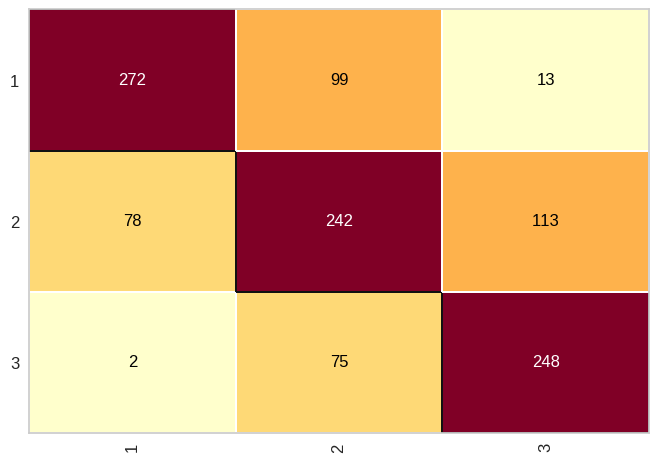

In [ ]:
#PLOTAGEM DA MATRIZ DE CONFUSÃO
from yellowbrick.classifier import ConfusionMatrix
confusion_matrix(y_teste, previsoes)
cm = ConfusionMatrix(modelo)
cm.fit(X_treino, y_treino)
cm.score(X_teste, y_teste)

In [ ]:
#FEATURE IMPORTANCE
importances = modelo.feature_importances_
feature_importance = pd.DataFrame({
    'Feature': X_treino.columns,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print(feature_importance)

                     Feature  Importance
2                  Nível_1.0    0.491207
3                  Nível_2.0    0.262606
8  Nivel_Experiencia_Ordinal    0.098937
9          Microsoft PowerBI    0.087580
5            Nivel_de_Ensino    0.029548
7   Grupo_Linguagens_Ordinal    0.018783
0                       IDHM    0.004656
6  Grupo_Ferramentas_Ordinal    0.003567
1                PIB_2021_OR    0.003116
4                  Nível_3.0    0.000000


<ipython-input-53-825512141>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


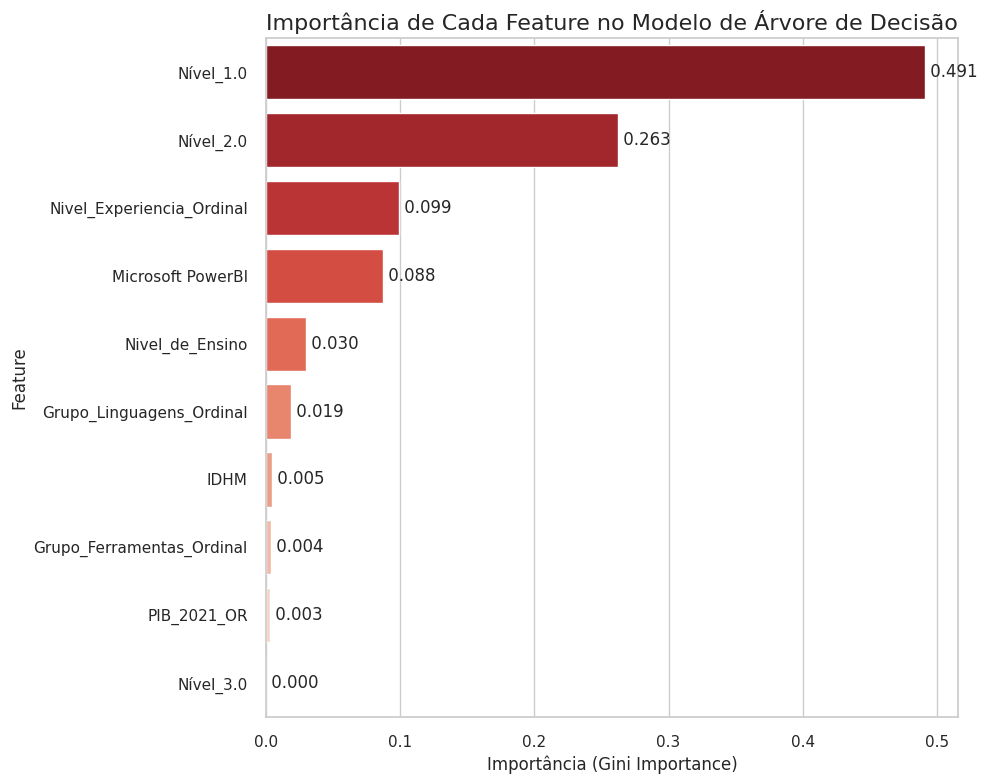

In [ ]:
# 1. Definir o estilo e o tamanho do gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 8))

# 2. Criar o gráfico de barras horizontais com Seaborn
barplot = sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance,
    palette='Reds_r',
    orient='h'
)

# 3. Adicionar título e rótulos
plt.title('Importância de Cada Feature no Modelo de Árvore de Decisão', fontsize=16)
plt.xlabel('Importância (Gini Importance)', fontsize=12)
plt.ylabel('Feature', fontsize=12)

# 4. Adicionar os valores de importância no final de cada barra
for index, value in enumerate(feature_importance['Importance']):
    plt.text(value, index, f' {value:.3f}', va='center')

# 5. Ajustar o layout e mostrar o gráfico
plt.tight_layout()
plt.show()

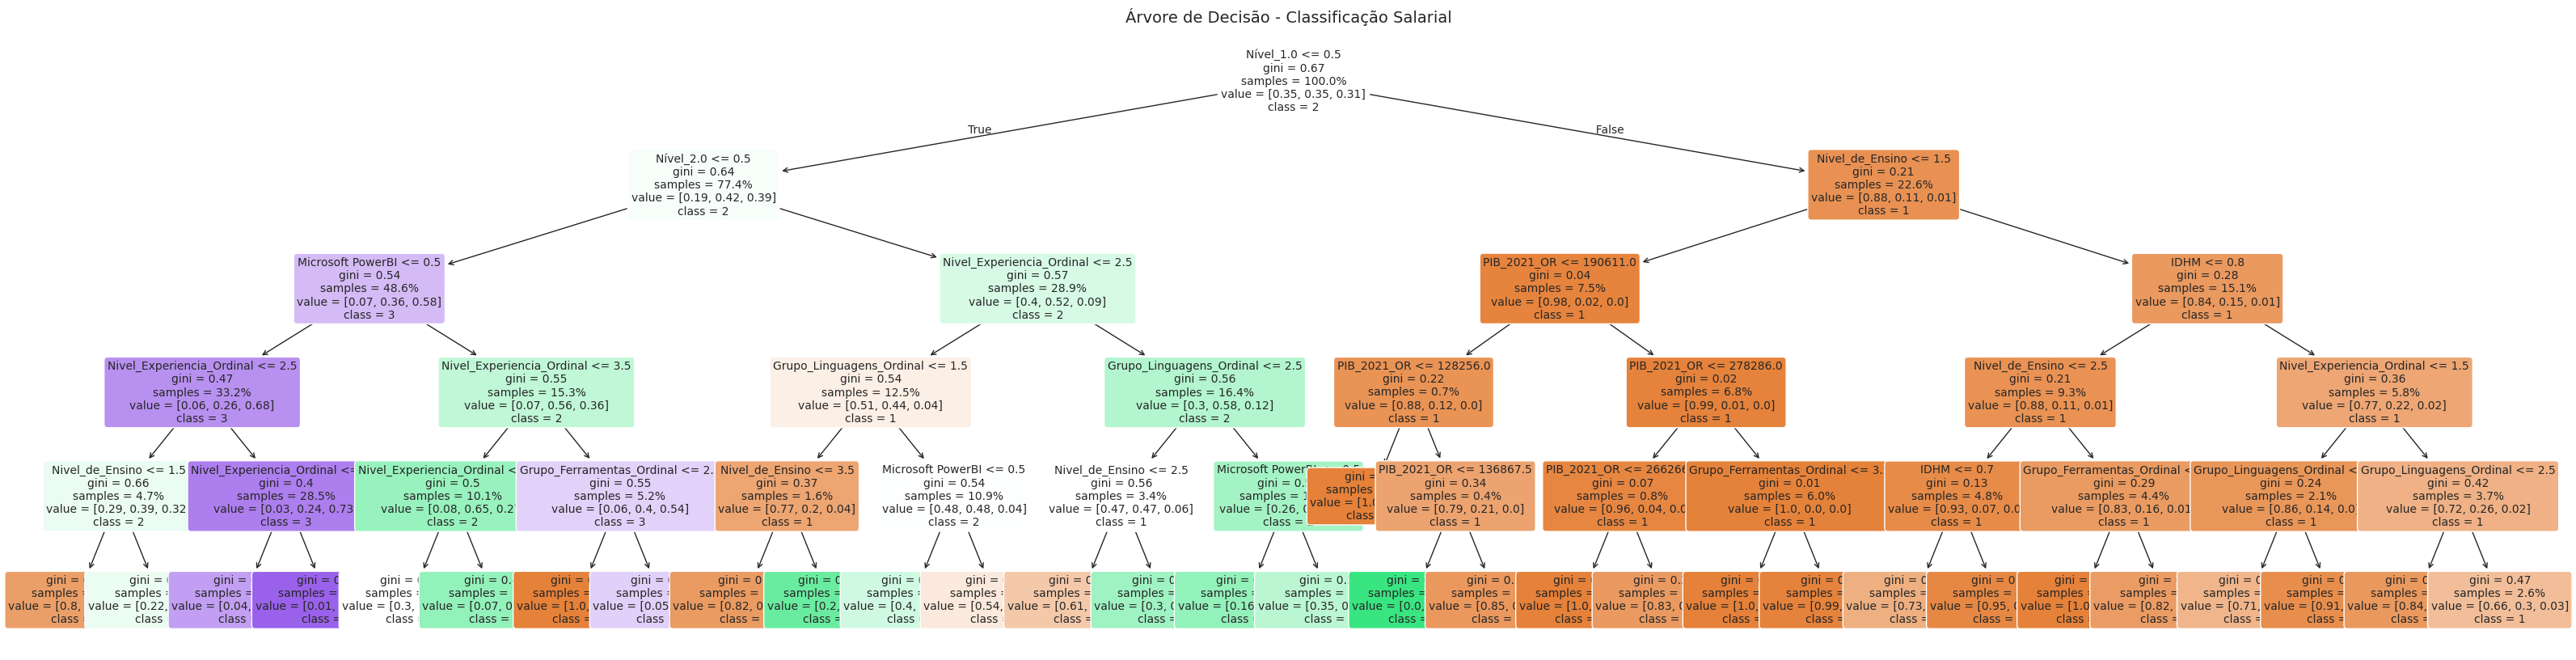

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Configurações para uma visualização clara
plt.figure(figsize=(40,10))

# Plot da árvore com parâmetros otimizados
plot_tree(modelo,
          feature_names=X_treino.columns.tolist(),  # Nomes das features
          class_names=['1', '2', '3', '4'],         # Nomes das classes
          filled=True,                              # Preenchimento de cores
          rounded=True,                             # Bordas arredondadas
          proportion=True,                          # Mostra proporções
          precision=2,                              # Casas decimais
          fontsize=10)                              # Tamanho da fonte

plt.title("Árvore de Decisão - Classificação Salarial", fontsize=14)
plt.show()

Valores ausentes em X_train ANTES do tratamento:
IDHM                         0
PIB_2021_OR                  0
Nível_1.0                    0
Nível_2.0                    0
Nível_3.0                    0
Nivel_de_Ensino              0
Grupo_Ferramentas_Ordinal    0
Grupo_Linguagens_Ordinal     0
Nivel_Experiencia_Ordinal    0
Microsoft PowerBI            0
dtype: int64
Acurácia de treino: 0.7108
Acurácia de teste: 0.6681


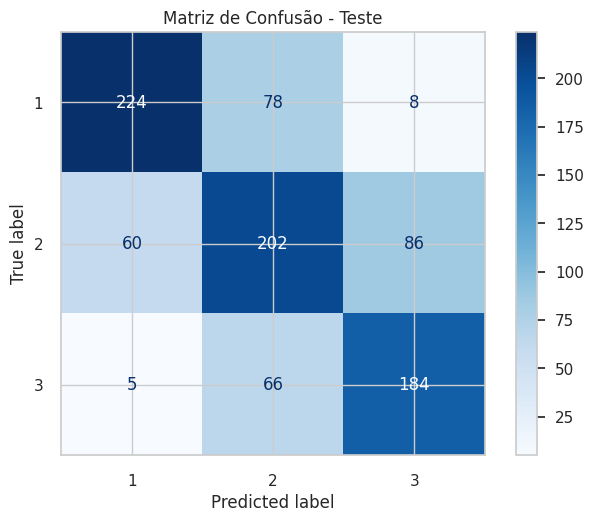


--- Resultados Detalhados do Modelo KNN no Conjunto de Teste ---

Acurácia no conjunto de teste: 0.67

Matriz de Confusão (Texto):
[[224  78   8]
 [ 60 202  86]
 [  5  66 184]]

Relatório de Classificação:
              precision    recall  f1-score   support

           1       0.78      0.72      0.75       310
           2       0.58      0.58      0.58       348
           3       0.66      0.72      0.69       255

    accuracy                           0.67       913
   macro avg       0.67      0.67      0.67       913
weighted avg       0.67      0.67      0.67       913


ANÁLISE DE PREVISÕES INDIVIDUAIS

✅ EXEMPLO DE SUCESSO:
IDHM                               0.806
PIB_2021_OR                  2719751.000
Nível_1.0                          0.000
Nível_2.0                          0.000
Nível_3.0                          1.000
Nivel_de_Ensino                    3.000
Grupo_Ferramentas_Ordinal          4.000
Grupo_Linguagens_Ordinal           3.000
Nivel_Experiencia_Ordinal  

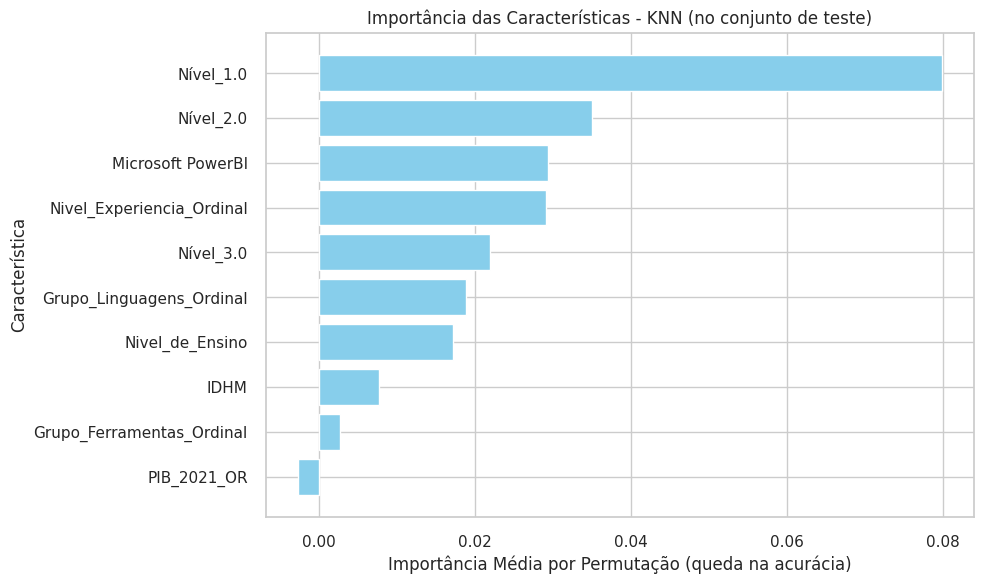

In [ ]:
### KNN ###
#KNN ou K-Vizinhos Mais Próximos
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

# Separando features (X) e target (y)
X = base_treino.drop('Salario_target', axis=1)
y = base_treino['Salario_target']

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verificando valores ausentes em X_train
print("Valores ausentes em X_train ANTES do tratamento:")
print(X_train.isnull().sum())

# Escalonamento dos dados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Treinamento do modelo KNN
knn = KNeighborsClassifier(n_neighbors=20)
knn.fit(X_train_scaled, y_train)

# Previsões
y_pred_train = knn.predict(X_train_scaled)
y_pred_test = knn.predict(X_test_scaled)

# Acurácia
acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

print(f"Acurácia de treino: {acc_train:.4f}")
print(f"Acurácia de teste: {acc_test:.4f}")

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn.classes_) # Adicionado display_labels
disp.plot(cmap='Blues')
plt.title("Matriz de Confusão - Teste")
plt.show()

print("\n--- Resultados Detalhados do Modelo KNN no Conjunto de Teste ---")


print(f"\nAcurácia no conjunto de teste: {acc_test:.2f}")

# 2. Matriz de Confusão (texto)
print("\nMatriz de Confusão (Texto):")
cm_text = confusion_matrix(y_test, y_pred_test)
print(cm_text)

# 3. Relatório de Classificação
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_test, zero_division=0)) # Adicionado zero_division=0

# --- IMPRESSÃO DE EXEMPLOS DE SUCESSO E FALHA ---

# Para garantir a visualização correta, usamos o X_test original (não escalonado)
# e alinhamos com os resultados de y_test e y_pred_test.
df_resultados = X_test.copy()
df_resultados['Nivel_Salarial_Real'] = y_test
df_resultados['Nivel_Salarial_Previsto'] = y_pred_test

# 1. Filtrar para obter apenas os sucessos (previsões corretas)
df_sucessos = df_resultados[df_resultados['Nivel_Salarial_Real'] == df_resultados['Nivel_Salarial_Previsto']]

# 2. Filtrar para obter apenas as falhas (previsões incorretas)
df_falhas = df_resultados[df_resultados['Nivel_Salarial_Real'] != df_resultados['Nivel_Salarial_Previsto']]


print("\n" + "="*50)
print("ANÁLISE DE PREVISÕES INDIVIDUAIS")
print("="*50)

# 3. Imprimir o primeiro exemplo de sucesso encontrado
if not df_sucessos.empty:
    print("\n✅ EXEMPLO DE SUCESSO:")
    # Usamos .iloc[0] para pegar a primeira linha do DataFrame de sucessos
    exemplo_sucesso = df_sucessos.iloc[0]
    print(exemplo_sucesso)
else:
    print("\nNenhum exemplo de sucesso encontrado no conjunto de teste.")

# 4. Imprimir o primeiro exemplo de falha encontrado
if not df_falhas.empty:
    print("\n❌ EXEMPLO DE FALHA:")
    # Usamos .iloc[0] para pegar a primeira linha do DataFrame de falhas
    exemplo_falha = df_falhas.iloc[0]
    print(exemplo_falha)
else:
    print("\nNenhum exemplo de falha encontrado no conjunto de teste. O modelo acertou tudo!")

print("\n" + "="*50)

# ---------------------------------------------------------------------------
# CÁLCULO DA IMPORTÂNCIA DAS CARACTERÍSTICAS USANDO PERMUTATION IMPORTANCE
# ---------------------------------------------------------------------------
print("\nCalculando a importância das características (usando o conjunto de teste)...")

result = permutation_importance(
    estimator=knn,
    X=X_test_scaled,  # Usando dados de teste para avaliação da importância
    y=y_test,
    scoring='accuracy', # Mesma métrica usada para avaliação do modelo, ou outra de interesse
    n_repeats=10,       # Número de repetições para maior robustez
    random_state=42,
    n_jobs=-1
)

# Extrair as importâncias médias
importances = result.importances_mean

# Obter os nomes das características
# X_train é o DataFrame ANTES do escalonamento e contém os nomes das colunas
feature_names = X_train.columns

# Criar o DataFrame de importância das características
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("\nImportância das Características (Permutation Importance - Teste):")
print(feature_importance_df)

# Plotar a importância das características
if not feature_importance_df.empty:
    plt.figure(figsize=(10, max(6, len(feature_names) * 0.5))) # Ajusta altura do gráfico
    plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
    plt.xlabel("Importância Média por Permutação (queda na acurácia)")
    plt.ylabel("Característica")
    plt.title("Importância das Características - KNN (no conjunto de teste)")
    plt.gca().invert_yaxis()  # Característica mais importante no topo
    plt.tight_layout()
    plt.show()
else:
    print("DataFrame de importância das características está vazio, não é possível plotar.")



Gerando a Curva de Aprendizado...


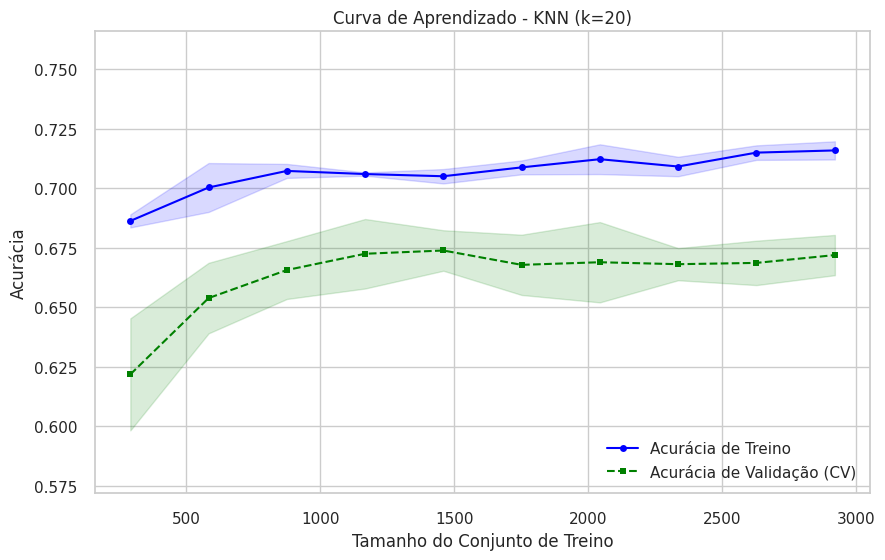

In [ ]:
# CURVA DE APRENDIZADO

from sklearn.model_selection import learning_curve

print("\nGerando a Curva de Aprendizado...")

estimator_for_lc = KNeighborsClassifier(n_neighbors=15)

# Gerando os dados para a Curva de Aprendizado
# Usamos X_train_scaled e y_train, pois o modelo é treinado com dados escalonados.
train_sizes, train_scores, test_scores = learning_curve(
    estimator=estimator_for_lc,
    X=X_train_scaled,
    y=y_train,
    cv=5,  # Número de folds para validação cruzada (pode ajustar)
    n_jobs=-1, # Usar todos os processadores
    train_sizes=np.linspace(0.1, 1.0, 10), # 10 tamanhos de treino, de 10% a 100%
    scoring='accuracy' # Métrica de avaliação
)

# Calculando médias e desvios padrão das pontuações
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plotando a Curva de Aprendizado
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean,
         color='blue', marker='o',
         markersize=5, label='Acurácia de Treino')

plt.fill_between(train_sizes,
                 train_mean + train_std,
                 train_mean - train_std,
                 alpha=0.15, color='blue')

plt.plot(train_sizes, test_mean,
         color='green', linestyle='--',
         marker='s', markersize=5,
         label='Acurácia de Validação (CV)')

plt.fill_between(train_sizes,
                 test_mean + test_std,
                 test_mean - test_std,
                 alpha=0.15, color='green')

plt.title(f'Curva de Aprendizado - KNN (k={knn.n_neighbors})') # Usa o k do seu modelo principal
plt.xlabel('Tamanho do Conjunto de Treino')
plt.ylabel('Acurácia')
plt.legend(loc='lower right')
plt.grid(True)
plt.ylim([min(test_mean.min(), train_mean.min()) - 0.05, max(test_mean.max(), train_mean.max()) + 0.05]) # Ajusta limites do eixo Y
plt.show()


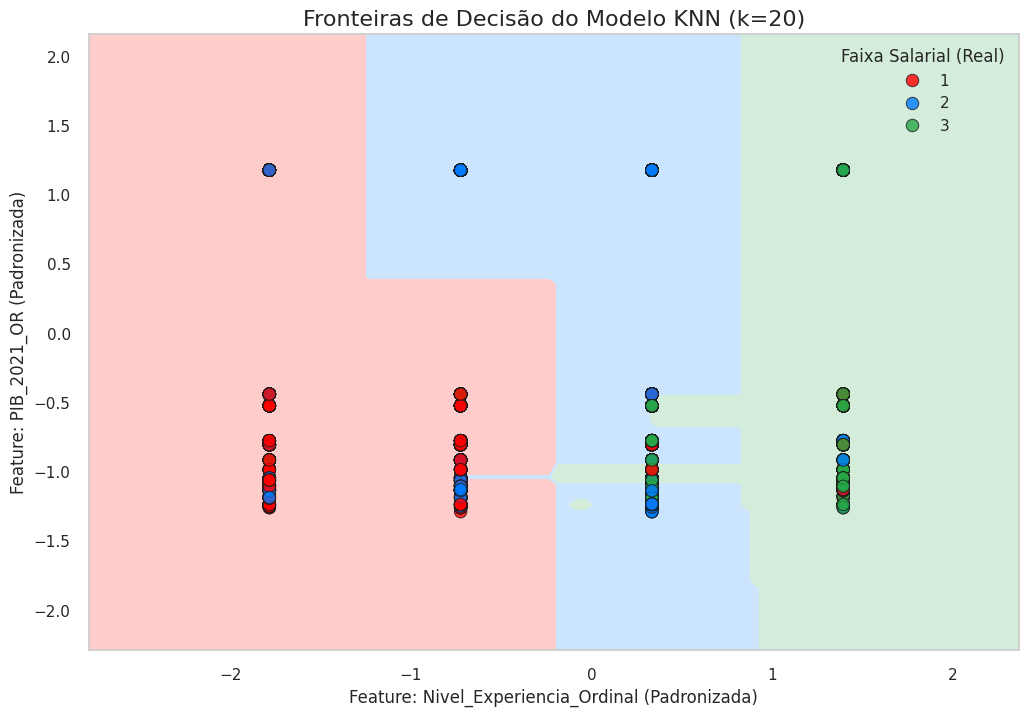

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# --- PASSO 1: Seleção dos Dados e Features para Visualização ---
# IMPORTANTE: Para visualizar, precisamos escolher as 2 features mais importantes.
# Verifique o gráfico de "Permutation Importance" do seu KNN e substitua os nomes abaixo se necessário.
# Vamos supor que as mais importantes foram 'Nivel_Experiencia_Ordinal' e 'PIB_2021_OR'.
feature1 = 'Nivel_Experiencia_Ordinal'
feature2 = 'PIB_2021_OR'

# Criando um novo DataFrame apenas com as 2 features e o target
X_2d = base_treino[[feature1, feature2]]
y_2d = base_treino['Salario_target']

# --- PASSO 2: Padronização dos Dados (essencial para KNN) ---
scaler_2d = StandardScaler()
X_2d_scaled = scaler_2d.fit_transform(X_2d)

# --- PASSO 3: Treinamento do Modelo KNN nos dados 2D ---
# Usamos os mesmos parâmetros do seu modelo original
knn_2d = KNeighborsClassifier(n_neighbors=20)
knn_2d.fit(X_2d_scaled, y_2d)

# --- PASSO 4: Preparação do Gráfico e da Grade de Pontos (Meshgrid) ---
# Criar uma paleta de cores para as classes de salário (Baixo, Médio, Alto)
cmap_light = ListedColormap(['#FFCCCC', '#CCE5FF', '#D4EDDA']) # Cores de fundo (Vermelho, Azul, Verde)
cmap_bold = ['#FF0000', '#007BFF', '#28A745']                # Cores dos pontos

# Definir os limites do gráfico
x_min, x_max = X_2d_scaled[:, 0].min() - 1, X_2d_scaled[:, 0].max() + 1
y_min, y_max = X_2d_scaled[:, 1].min() - 1, X_2d_scaled[:, 1].max() + 1

# Criar a grade de pontos para colorir o fundo
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

# Fazer predições para cada ponto na grade
Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# --- PASSO 5: Plotagem do Gráfico Final ---
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# Plotar as áreas de decisão (fundo colorido)
plt.contourf(xx, yy, Z, cmap=cmap_light)

# Plotar os pontos de dados reais
sns.scatterplot(x=X_2d_scaled[:, 0], y=X_2d_scaled[:, 1], hue=y_2d,
                palette=cmap_bold, alpha=0.8, edgecolor="k", s=80)

# Configurações finais do gráfico
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.title(f'Fronteiras de Decisão do Modelo KNN (k=20)', fontsize=16)
plt.xlabel(f'Feature: {feature1} (Padronizada)', fontsize=12)
plt.ylabel(f'Feature: {feature2} (Padronizada)', fontsize=12)
plt.legend(title='Faixa Salarial (Real)', loc='best')

plt.show()